In [93]:
!pip install torchvision

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB 320.0 kB/s eta 0:00:06
   - -------------------------------------- 0.1/1.7 MB 544.7 kB/s eta 0:00:04
   ----- ---------------------------------- 0.2/1.7 MB 1.4 MB/s eta 0:00:02
   ------------ --------------------------- 0.5/1.7 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------  1.7/1.7 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


100%|██████████| 9.91M/9.91M [00:03<00:00, 3.20MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 255kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.12MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.27MB/s]


Epoch 1/10 | Train Loss: 0.4785 Acc: 0.8660 | Val Loss: 0.3501 Acc: 0.8974
Epoch 2/10 | Train Loss: 0.3270 Acc: 0.9048 | Val Loss: 0.3473 Acc: 0.8957
Epoch 3/10 | Train Loss: 0.3099 Acc: 0.9107 | Val Loss: 0.3288 Acc: 0.9030
Epoch 4/10 | Train Loss: 0.3003 Acc: 0.9133 | Val Loss: 0.3160 Acc: 0.9074
Epoch 5/10 | Train Loss: 0.2948 Acc: 0.9165 | Val Loss: 0.3249 Acc: 0.9082
Epoch 6/10 | Train Loss: 0.2912 Acc: 0.9181 | Val Loss: 0.3306 Acc: 0.8985
Epoch 7/10 | Train Loss: 0.2883 Acc: 0.9180 | Val Loss: 0.3173 Acc: 0.9094
Epoch 8/10 | Train Loss: 0.2845 Acc: 0.9194 | Val Loss: 0.3083 Acc: 0.9096
Epoch 9/10 | Train Loss: 0.2814 Acc: 0.9206 | Val Loss: 0.3007 Acc: 0.9140
Epoch 10/10 | Train Loss: 0.2809 Acc: 0.9207 | Val Loss: 0.2987 Acc: 0.9141


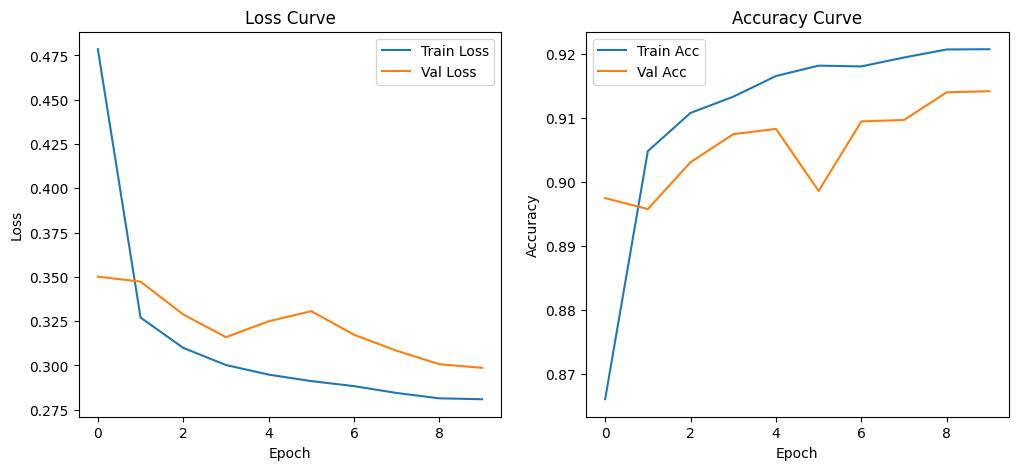

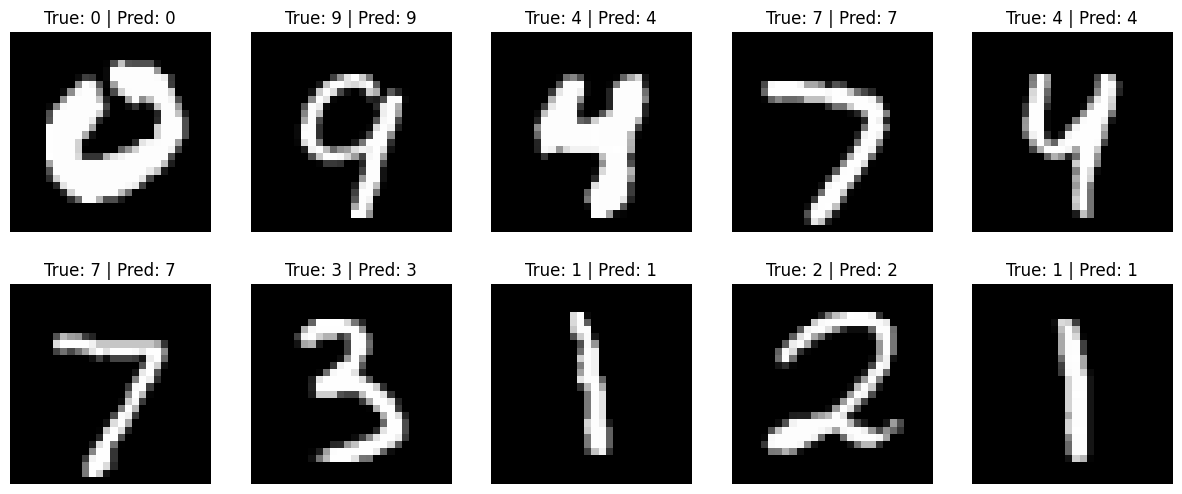

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import random

# 1. Load Sign Language MNIST dataset (28x28 grayscale images)
# Note: torchvision does not have sign language mnist by default, so use regular MNIST or you can replace dataset path if you have SL MNIST locally.

# For demo, let's use regular MNIST (28x28 grayscale) since SL MNIST is similar in format
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize grayscale images
])

# Download MNIST (can replace with your own Kaggle dataset loader)
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split train into train/val (90/10)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# 2. Define a simple linear model (one linear layer)
class SimpleLinearNN(nn.Module):
    def __init__(self):
        super().__init__()
        # MNIST image size 28*28 = 784 inputs
        self.fc = nn.Linear(28*28, 10)
    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten images
        return self.fc(x)

model = SimpleLinearNN()

# 3. Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Training loop with loss and accuracy tracking
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return torch.sum(preds == labels).item() / len(labels)

num_epochs = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    running_acc = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_acc += accuracy(outputs, labels)
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(running_acc / len(train_loader))
    
    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_acc += accuracy(outputs, labels)
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_acc / len(val_loader))
    
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accuracies[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f} Acc: {val_accuracies[-1]:.4f}")

# 5. Plot loss and accuracy curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# 6. Visualize 10 random test images with predictions
model.eval()
test_images, test_labels = next(iter(test_loader))  # grab first batch
indices = random.sample(range(len(test_images)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15,6))
for i, idx in enumerate(indices):
    img = test_images[idx]
    label = test_labels[idx].item()
    
    output = model(img.unsqueeze(0))
    pred = torch.argmax(output, 1).item()
    
    ax = axes[i//5, i%5]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"True: {label} | Pred: {pred}")
    ax.axis('off')
plt.show()
